## Table of Contents
1. [Introduction and Setup](#Introduction-and-Setup)
2. [Data Loading](#Data-Loading)
3. [Initial Data Exploration](#Initial-Data-Exploration)
    - [DataFrame Head and Info](#DataFrame-Head-and-Info)
    - [Summary Statistics](#Summary-Statistics)
4. [Data Grouping and Aggregation](#Data-Grouping-and-Aggregation)
    - [Grouping by Assignment Group](#Grouping-by-Assignment-Group)
5. [Data Visualization](#Data-Visualization)
    - [Ticket Count by Assignment Group (Plotly)](#Ticket-Count-by-Assignment-Group-(Plotly))
6. [Conclusion](#Conclusion)

## Overview: Model Selection, Model 2
In this notebook we implement the first analytical model. Model 2 focusses on the number of tickets resolved by each support group in Q2 2016. 
1. A small group of support groups account for most ticket closures
2. Many support groups (four from model 1 results) work on longer activity tickets
   

In [1]:
from importlib.resources import files
import pandas as pd
fp = str(files("kmds.examples").joinpath("q2_2016_ticket_resolution_data.csv"))
df = pd.read_csv(fp)
df.head()

,number,sys_created_at,closed_at,assignment_group
0,INC0000045,2016-02-29 01:23:00,2016-05-03 12:00:00,Group 56
1,INC0000047,2016-02-29 04:57:00,2016-06-03 10:00:00,Group 24
2,INC0000062,2016-02-29 07:26:00,2016-05-03 16:00:00,Group 23
3,INC0000063,2016-02-29 07:17:00,2016-05-03 17:00:00,Group 23
4,INC0000071,2016-02-29 08:17:00,2016-06-03 11:00:00,Group 24


In [2]:
fpdtypes = str(files("kmds.examples").joinpath("ticket_resolution_dtypes.csv"))
dtypes_df = pd.read_csv(fpdtypes)
dtypes_dict = {row["attribute"]: row["type"] for index, row in dtypes_df.iterrows()}
df = df.astype(dtypes_dict)
df = df.reset_index()

In [3]:
df.dtypes

index                        int64
number                         str
sys_created_at      datetime64[ns]
closed_at           datetime64[ns]
assignment_group               str
dtype: object

In [4]:
dsbyag = df.groupby([df.sys_created_at.dt.day_of_year, df.assignment_group])
dsbyag = dsbyag["assignment_group"].size().reset_index(name="ticket_count")
dsbyag.columns = ["DOY", "assingment_group","ticket_count"] 
#dfQ1_PA = dsbysc.pivot(index="InvoiceDate", columns="StockCode", values="item_total").fillna(0)

In [5]:
#dsbyag.pivot(index="DOY", columns="assingment_group", values="ticket_count").fillna(0)

In [6]:
sggb = df.groupby("assignment_group").size().reset_index(name="ticket_count")

In [7]:
sggb.sort_values(["ticket_count"], ascending=False)

,assignment_group,ticket_count
26,Group 39,396
13,Group 25,319
12,Group 24,304
11,Group 23,174
8,Group 20,153
15,Group 27,150
0,Group 10,135
16,Group 28,125
48,Group 64,123
10,Group 22,115


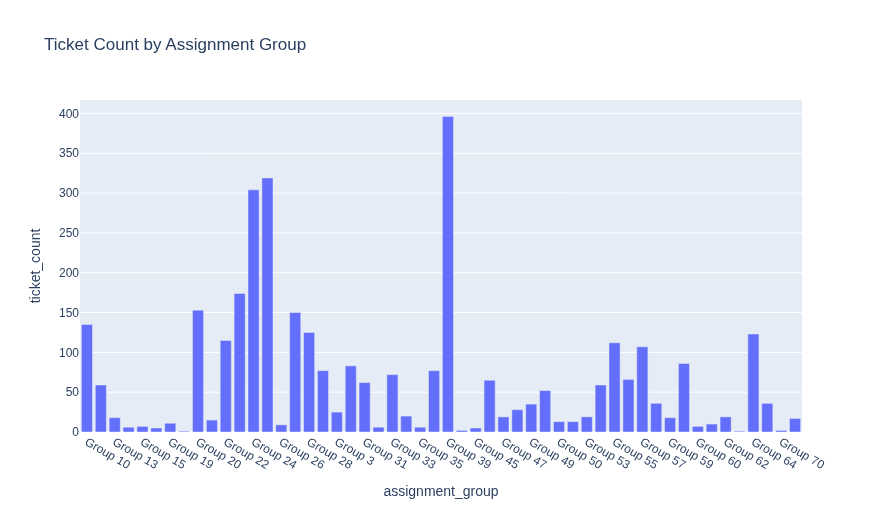

In [14]:
import plotly.express as px

# Create an interactive bar chart using the sggb DataFrame
# I'm setting a specific width and height to ensure readability
fig = px.bar(
    sggb, 
    x='assignment_group', 
    y='ticket_count',
    title='Ticket Count by Assignment Group',
    width=950,
    height=500
)

# Display the figure in the notebook
fig.show()

In [8]:
from kmds.tagging.tag_types import ModelSelectionTags
from owlready2 import *
from kmds.utils.load_utils import *
#from utils.path_utils import *
KNOWLEDGE_BASE = str(files("kmds.examples").joinpath("example_analytics_kb_app_workflow.xml"))

* Owlready2 * Warning: optimized Cython parser module 'owlready2_optimized' is not available, defaulting to slower Python implementation


In [9]:
onto2 = load_kb(KNOWLEDGE_BASE)

In [10]:
with onto2:
    insts = Workflow.instances()
the_workflow_instance = insts[0]

In [11]:
the_workflow_instance.has_model_selection_observations

[example_analytics_kb_app_workflow.xml.modelselectionobservation1,
 example_analytics_kb_app_workflow.xml.modelselectionobservation2,
 example_analytics_kb_app_workflow.xml.modelselectionobservation3,
 example_analytics_kb_app_workflow.xml.modelselectionobservation4]

In [12]:
from kmds.ontology.intent_types import IntentType
ms_obs_list = []
observation_count = 1

ms1 = ModelSelectionObservation(namespace=onto2)
ms1.finding = "A small group of support groups account for most ticket closures"
ms1.finding_sequence = observation_count
ms1.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_OBSERVATION.value
ms1.intent = IntentType.MODEL_SELECTION.value
ms_obs_list.append(ms1)
observation_count += 1

ms2 = ModelSelectionObservation(namespace=onto2)
ms2.finding = "Many support groups (four from model 1 results) work on longer activity tickets"
ms2.finding_sequence = observation_count
ms2.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_OBSERVATION.value
ms2.intent = IntentType.MODEL_SELECTION.value
ms_obs_list.append(ms2)


the_workflow_instance.has_model_selection_observations = (the_workflow_instance.has_model_selection_observations + ms_obs_list)

onto2.save(file=KNOWLEDGE_BASE, format="rdfxml")

In [13]:
the_workflow_instance.has_model_selection_observations

[example_analytics_kb_app_workflow.xml.modelselectionobservation1,
 example_analytics_kb_app_workflow.xml.modelselectionobservation2,
 example_analytics_kb_app_workflow.xml.modelselectionobservation3,
 example_analytics_kb_app_workflow.xml.modelselectionobservation4,
 example_analytics_kb_app_workflow.xml.modelselectionobservation5,
 example_analytics_kb_app_workflow.xml.modelselectionobservation6]